
# Import and Preprocess

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from IPython.display import display

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

pio.renderers.default = "browser"

In [ ]:

df_jump_cmps = pd.read_parquet("<path_to_a_parquet_with_metadata_and_embeddings>")

In [19]:
df_jump_cmps

,Metadata_JCP2022,Metadata_InChI,Embeddings_mean,Metadata_Is_Control,path_embedding,PhenotypicProfile
0,JCP2022_005859,InChI=1S/C25H33N5O/c1-5-28-11-13-29(14-12-28)1...,"[-0.982317, 0.22172618, 0.029495342, -0.106136...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.9823169708251953, 0.2217261791229248, 0.02..."
1,JCP2022_026950,InChI=1S/C21H17N3O/c25-20(24-21-22-18-8-4-5-9-...,"[-0.10979553, 0.18473738, 0.034682225, -0.0029...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.10979553312063217, 0.18473738431930542, 0...."
2,JCP2022_063677,InChI=1S/C9H10O3S/c1-12-9(11)5-4-7(10)8-3-2-6-...,"[-0.5687139, 0.11661118, -0.700688, 1.3592801,...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.568713903427124, 0.11661118268966675, -0.7..."
3,JCP2022_079597,InChI=1S/C24H20N2O7S/c1-31-21-10-6-4-8-18(21)2...,"[0.18552876, -0.2230738, 1.6004194, -0.8870724...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[0.18552875518798828, -0.2230737954378128, 1.6..."
4,JCP2022_033442,InChI=1S/C23H21N3O6/c1-25(16-6-4-3-5-7-16)22(2...,"[-0.34019136, 0.29544798, 0.11834066, 0.119887...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.3401913642883301, 0.29544797539711, 0.1183..."
...,...,...,...,...,...,...
112600,JCP2022_031885,InChI=1S/C12H21NO/c1-9-5-2-3-8-11(9)13-12(14)1...,"[0.38655844, -0.6434984, 0.4539342, -0.2146197...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[0.3865584433078766, -0.643498420715332, 0.453..."
112601,JCP2022_115012,InChI=1S/C19H20N2O3S/c1-24-19-10-6-16(7-11-19)...,"[-0.16721995, 0.14565137, -0.07568514, -0.2558...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.16721995174884796, 0.14565137028694153, -0..."
112602,JCP2022_107352,InChI=1S/C12H11NO3/c1-2-16-12(15)9-7-13-10-6-4...,"[-0.10215604, -0.055829696, 0.5230895, 0.16043...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.10215604305267334, -0.055829696357250214, ..."
112603,JCP2022_069776,InChI=1S/C10H16N4O4S/c1-7-8(9(15)12-10(16)11-7...,"[-0.16962965, 0.18303728, 0.5590696, -0.565142...",False,/projects/synsight/data/openphenom/norm_2_comp...,"[-0.16962964832782745, 0.18303728103637695, 0...."


In [20]:
def compute_murcko_scaffold(inchi):
    try:
        mol = Chem.MolFromInchi(inchi)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except Exception as e:
        return None


df_jump_cmps["Murcko_Scaffold"] = df_jump_cmps["Metadata_InChI"].apply(
    compute_murcko_scaffold
)

[17:30:44] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Locations or number, Number; Mobile-H groups: One instead of multiple, Attachment points, Number; Charge(s): Do not match)

[17:30:44] Explicit valence for atom # 32 P, 6, is greater than permitted
[17:30:44] ERROR: Explicit valence for atom # 32 P, 6, is greater than permitted

[17:30:44] Explicit valence for atom # 26 P, 6, is greater than permitted
[17:30:44] ERROR: Explicit valence for atom # 26 P, 6, is greater than permitted

[17:30:45] Explicit valence for atom # 29 P, 6, is greater than permitted
[17:30:45] ERROR: Explicit valence for atom # 29 P, 6, is greater than permitted

[17:30:45] Explicit valence for atom # 10 P, 6, is greater than permitted
[17:30:45] ERROR: Explicit valence for atom # 10 P, 6, is greater than permitted

[17:30:45] Explicit valence for atom # 17 P, 6, is greater than permitted
[17:30:45] ERROR: Explicit valence for atom # 17 P, 6, is greater than permitted

[17:30:46] Explicit valence for a

In [21]:
df_jump_cmps.drop(
    columns=["Metadata_Is_Control", "path_embedding", "Embeddings_mean"], inplace=True
)

# Exemple of scaffold

In [22]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Your InChI
inchi_str = "InChI=1/C19H33N3O6/c1-5-9-20-16(23)14-15(28-14)17(24)21-13(11(3)6-2)18(25)22-10-7-8-12(22)19(26)27-4/h11-15,18,25H,5-10H2,1-4H3,(H,20,23)(H,21,24)"

# 1) Conversion InChI -> Mol
mol = Chem.MolFromInchi(inchi_str)

# 2) Calcul du scaffold (Bemis-Murcko)
scaffold = MurckoScaffold.GetScaffoldForMol(mol)

# 3) Extraction du SMILES
scaffold_smiles = Chem.MolToSmiles(scaffold)
print(scaffold_smiles)

C(=NCCN1CCCC1)C1CO1


In [23]:
df_jump_cmps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112605 entries, 0 to 112604
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Metadata_JCP2022   112605 non-null  object
 1   Metadata_InChI     112605 non-null  object
 2   PhenotypicProfile  112605 non-null  object
 3   Murcko_Scaffold    112549 non-null  object
dtypes: object(4)
memory usage: 3.4+ MB


In [24]:
df_jump_cmps[
    df_jump_cmps["Metadata_InChI"]
    == "InChI=1S/C15H12N2O2/c16-15(19)17-12-7-3-1-5-10(12)9-14(18)11-6-2-4-8-13(11)17/h1-8H,9H2,(H2,16,19)"
]

,Metadata_JCP2022,Metadata_InChI,PhenotypicProfile,Murcko_Scaffold
16232,JCP2022_013346,InChI=1S/C15H12N2O2/c16-15(19)17-12-7-3-1-5-10...,"[0.32751086354255676, -0.4196804165840149, 0.7...",O=C1Cc2ccccc2Nc2ccccc21


# A lot of functions

In [25]:
def filter_molecules_by_scaffold(df, scaffold_smiles):
    return df[df["Murcko_Scaffold"] == scaffold_smiles]


def compute_phenotypic_similarity(df):
    embeddings = np.stack(df["PhenotypicProfile"])
    similarity_matrix = cosine_similarity(embeddings)
    return similarity_matrix


# Fonction pour calculer les Tanimoto Similarities
def compute_tanimoto_similarities(df):
    fps = [
        AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromInchi(inchi), radius=2)
        for inchi in df["Metadata_InChI"]
    ]
    tanimoto_matrix = np.zeros((len(fps), len(fps)))
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            tanimoto_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            tanimoto_matrix[j, i] = tanimoto_matrix[i, j]
    return tanimoto_matrix

In [26]:
def process_murkos(df, n_threshold, m_values):
    # Group by Murcko scaffold
    grouped = df.groupby("Murcko_Scaffold")
    results = []

    for scaffold, group in tqdm(grouped):
        if len(group) > n_threshold:
            phenotypic_profiles = np.stack(group["PhenotypicProfile"].values)

            # Compute similarities within and between clusters
            tanimoto_sim_matrix = compute_tanimoto_similarities(
                df[df["Murcko_Scaffold"] == scaffold]
            )
            cosine_sim_matrix = cosine_similarity(phenotypic_profiles)

            for m in m_values:
                # Perform hierarchical clustering
                distance_matrix = pdist(phenotypic_profiles, metric="euclidean")
                linkage_matrix = linkage(distance_matrix, method="ward")
                cluster_labels = fcluster(linkage_matrix, m, criterion="maxclust")

                # Check if any cluster has fewer than 3 molecules
                cluster_sizes = np.bincount(cluster_labels)[
                    1:
                ]  # Cluster sizes, excluding cluster 0
                if np.any(cluster_sizes < 3):
                    continue  # Skip this clustering

                intra_tanimoto = []
                intra_cosine = []
                inter_tanimoto = []
                inter_cosine = []

                for cluster in range(1, m + 1):
                    indices = np.where(cluster_labels == cluster)[0]
                    if len(indices) > 1:
                        # Mask diagonal for intra-cluster calculations
                        mask = np.ones((len(indices), len(indices)), dtype=bool)
                        np.fill_diagonal(mask, False)
                        intra_tanimoto.append(
                            np.mean(tanimoto_sim_matrix[np.ix_(indices, indices)][mask])
                        )
                        intra_cosine.append(
                            np.mean(cosine_sim_matrix[np.ix_(indices, indices)][mask])
                        )
                for i in range(1, m + 1):
                    for j in range(i + 1, m + 1):
                        indices_i = np.where(cluster_labels == i)[0]
                        indices_j = np.where(cluster_labels == j)[0]
                        if indices_i.size > 0 and indices_j.size > 0:
                            inter_tanimoto.append(
                                np.mean(
                                    tanimoto_sim_matrix[np.ix_(indices_i, indices_j)]
                                )
                            )
                            inter_cosine.append(
                                np.mean(cosine_sim_matrix[np.ix_(indices_i, indices_j)])
                            )

                results.append(
                    {
                        "Scaffold": scaffold,
                        "n_Scaffold": len(group),
                        "ClusterCount": m,
                        "IntraTanimoto": (
                            np.mean(intra_tanimoto) if intra_tanimoto else None
                        ),
                        "IntraCosine": np.mean(intra_cosine) if intra_cosine else None,
                        "InterTanimoto": (
                            np.mean(inter_tanimoto) if inter_tanimoto else None
                        ),
                        "InterCosine": np.mean(inter_cosine) if inter_cosine else None,
                    }
                )
    return pd.DataFrame(results)

In [27]:
def plot_analysis(results_df):
    plt.style.use("default")  # Clean and simple aesthetic

    fig1, ax1 = plt.subplots(figsize=(15, 8))

    selected = results_df["Selected_Scaffold"]
    ax1.tick_params(axis="both", which="major", labelsize=20)
    ax1.grid(True, linestyle="--", alpha=0.7)  # Add grid
    ax1.plot(
        [0, 0.82],
        [0, 0.82],  # Diagonal line y = x
        color="black",
        linewidth=2,
        alpha=0.8,
        label="y = x",
    )

    #   ax1.plot(
    #       [0.3, 0.8], [0.1, 0.6],  # Offset line y = x - 0.2
    #       color='red', linestyle='--', linewidth=1, alpha=0.8, label='y = x - 0.2'
    #   )

    ax1.set_ylim(-0.2, 0.82)
    ax1.set_xlim(0, 0.8)

    ax1.scatter(
        results_df.loc[~selected, "IntraTanimoto"],
        results_df.loc[~selected, "InterTanimoto"],
        alpha=0.3,
        s=100,
        edgecolors="k",
        color="gray",
        marker="x",
    )
    ax1.scatter(
        results_df.loc[selected, "IntraTanimoto"],
        results_df.loc[selected, "InterTanimoto"],
        alpha=0.8,
        s=100,
        edgecolors="k",
        color="blue",
    )

    ax1.legend(
        fontsize=30, loc="upper left", frameon=True, framealpha=0.9
    )  # Increased font size

    plt.tight_layout()
    plt.savefig(
        "structural_tanimoto_plot.pdf", format="pdf", dpi=300
    )  # Save the plot as a high-res PDF
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(15, 8))
    ax2.tick_params(axis="both", which="major", labelsize=20)
    ax2.grid(True, linestyle="--", alpha=0.7)  # Add grid
    ax2.set_xlim(0, 0.8)
    ax2.set_ylim(-0.2, 0.82)

    ax2.plot(
        [0, 0.8],
        [0, 0.8],  # Diagonal line y = x
        color="black",
        linewidth=2,
        alpha=0.8,
        label="y = x",
    )

    ax2.plot(
        [0, 0.8],
        [-0.2, 0.6],  # Offset line y = x - 0.2
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label="y = x - 0.2",
    )

    ax2.scatter(
        results_df.loc[~selected, "IntraCosine"],
        results_df.loc[~selected, "InterCosine"],
        alpha=0.3,
        s=100,
        edgecolors="k",
        color="gray",
        marker="x",
    )
    ax2.scatter(
        results_df.loc[selected, "IntraCosine"],
        results_df.loc[selected, "InterCosine"],
        alpha=0.8,
        s=100,
        edgecolors="k",
        color="darkred",
    )

    ax2.legend(
        fontsize=30, loc="upper left", frameon=True, framealpha=0.9
    )  # Increased font size

    plt.tight_layout()
    plt.savefig(
        "phenotypic_cosine_plot.pdf", format="pdf", dpi=300
    )  # Save the plot as a high-res PDF
    plt.show()

# Find Murko Cluster 

In [28]:
scaffold_counts = df_jump_cmps["Murcko_Scaffold"].value_counts()
scaffold_counts.head(5)

Murcko_Scaffold
c1ccccc1                      1350
                               376
c1ccncc1                       214
O=S(=O)(Nc1ccccc1)c1ccccc1     158
C(=Nc1ccccc1)c1ccccc1          157
Name: count, dtype: int64

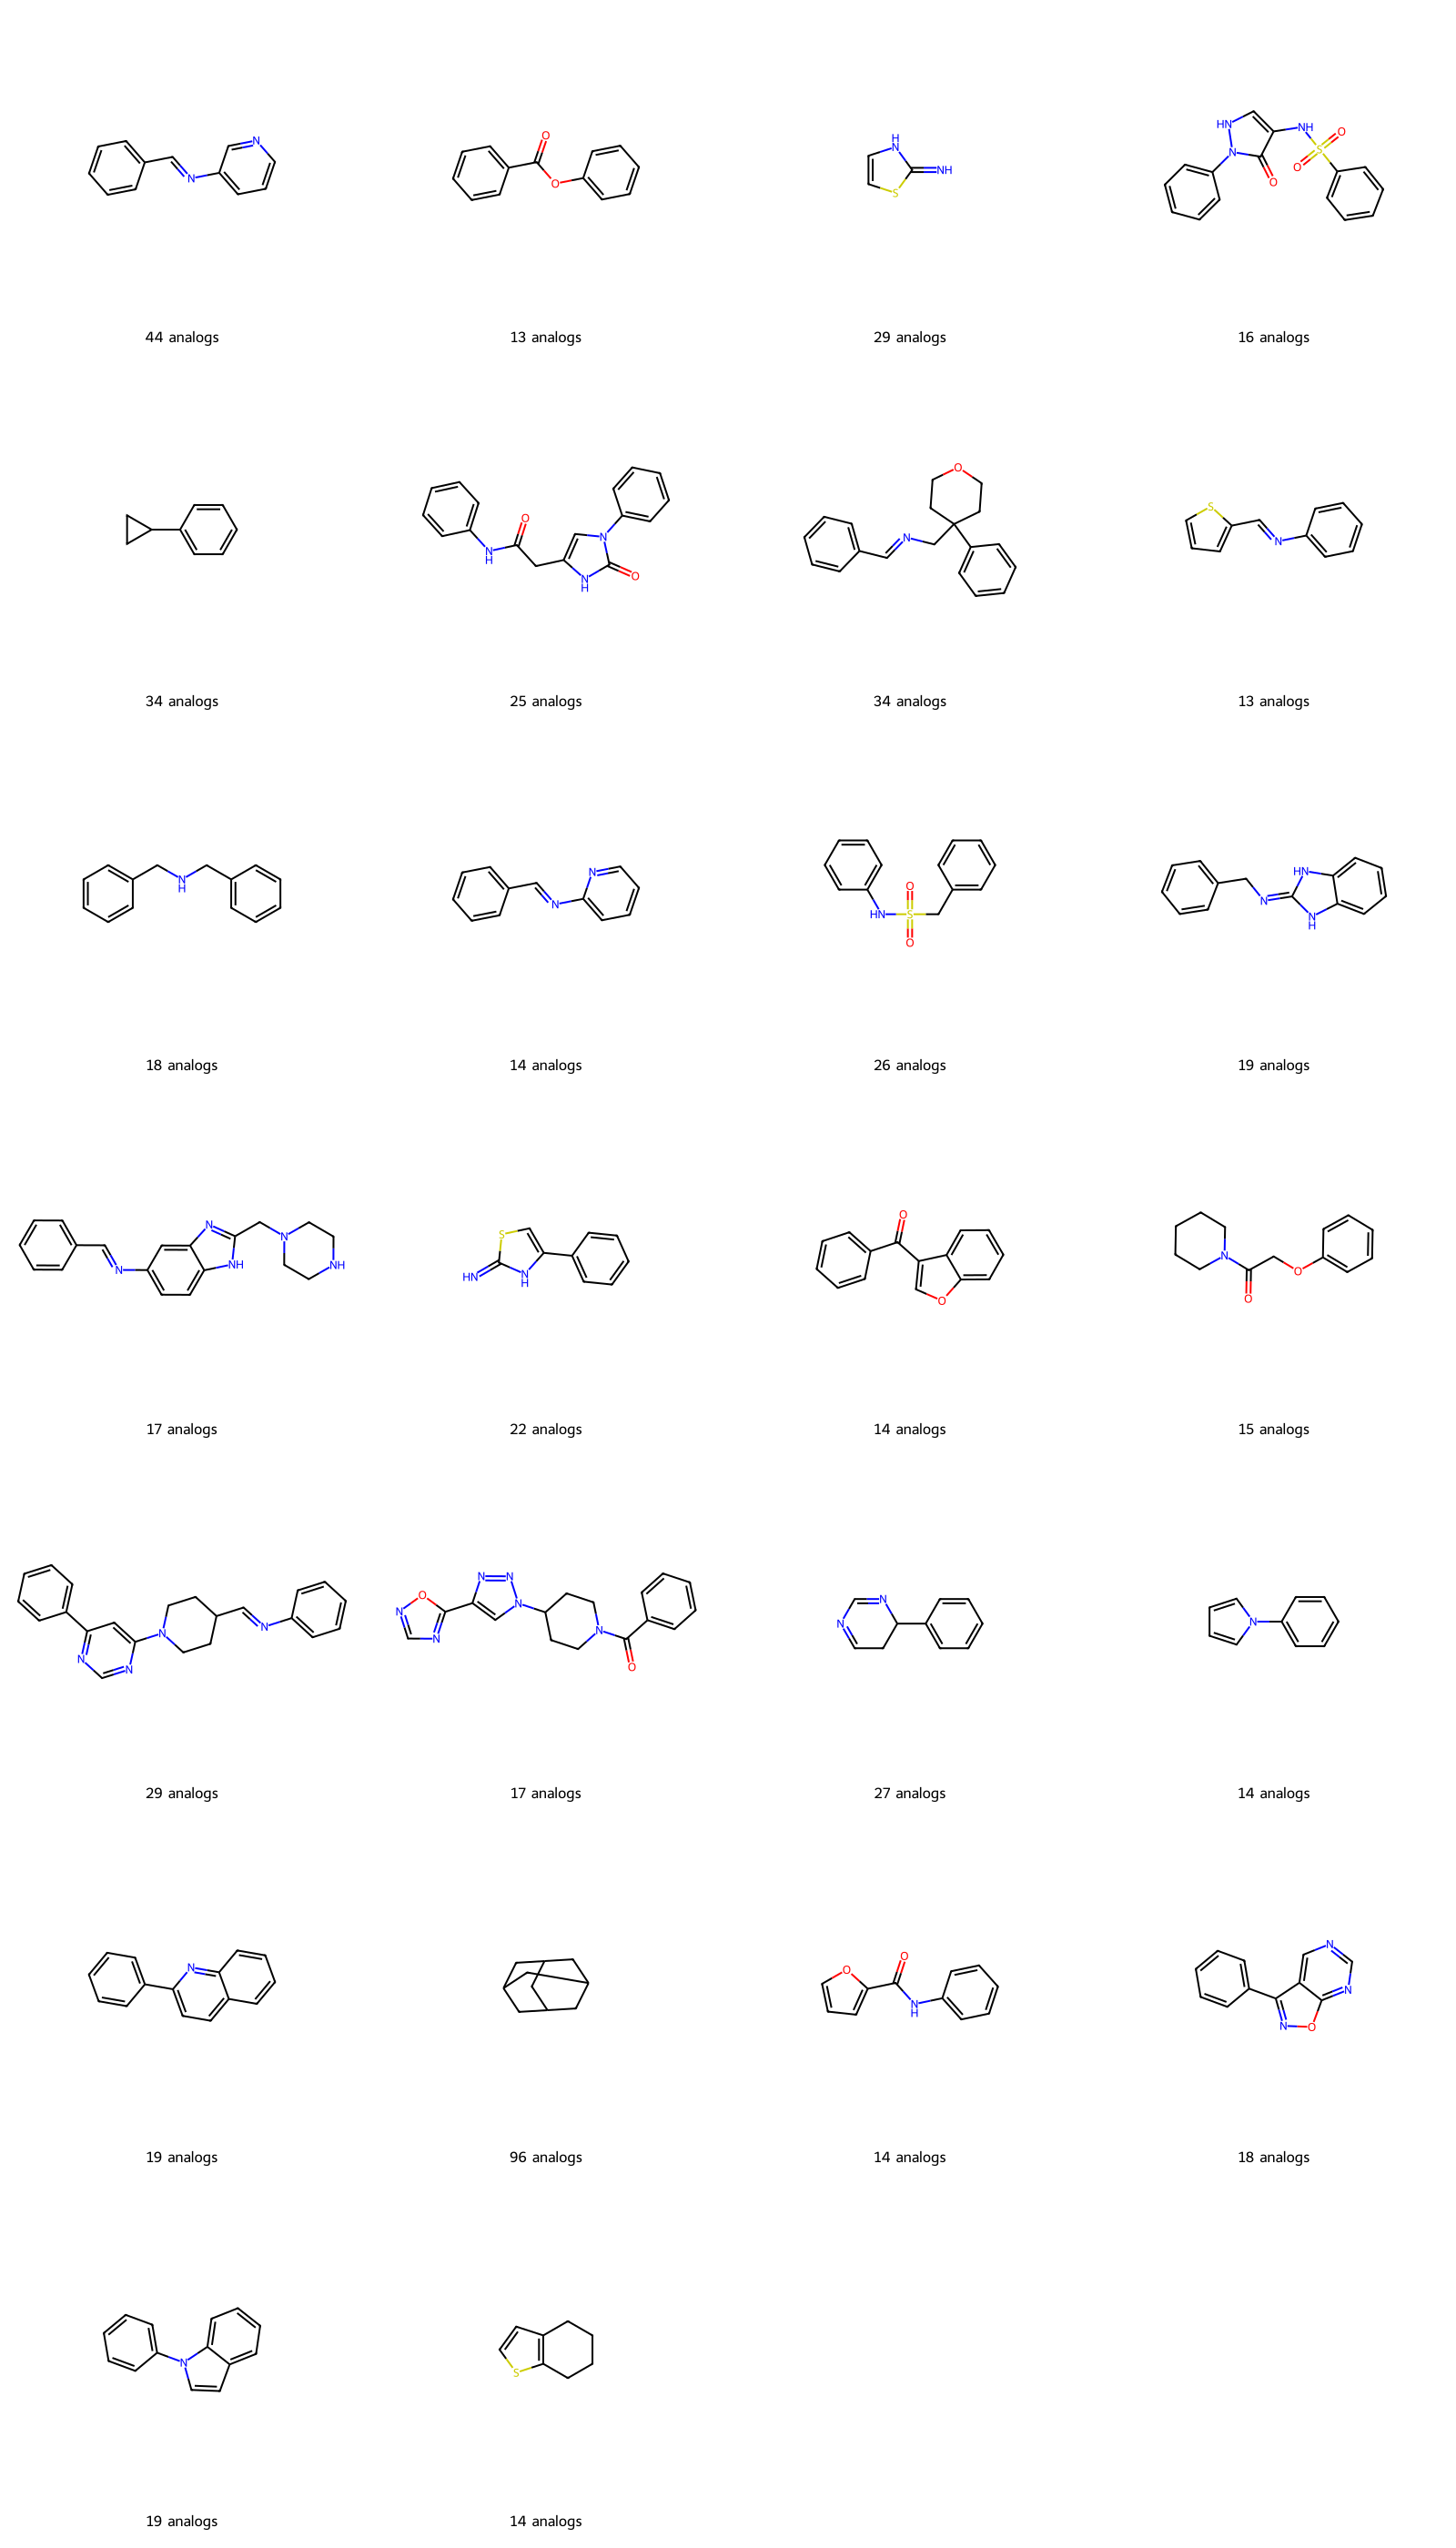

In [29]:
top_scaffolds = scaffold_counts.head(400).sample(28).index
frequencies = scaffold_counts.head(400).sample(28).values
mols = [Chem.MolFromSmiles(smiles) for smiles in top_scaffolds]

legends = [f"{freq} analogs" for freq in frequencies]

img = Draw.MolsToGridImage(
    mols[2:], molsPerRow=4, subImgSize=(400, 400), legends=legends[2:]
)

display(img)

# Scrapping Scaffold - Fig 4 & Sup

In [30]:
df_jump_cmps

,Metadata_JCP2022,Metadata_InChI,PhenotypicProfile,Murcko_Scaffold
0,JCP2022_005859,InChI=1S/C25H33N5O/c1-5-28-11-13-29(14-12-28)1...,"[-0.9823169708251953, 0.2217261791229248, 0.02...",C(=Nc1ccc2[nH]c(CN3CCNCC3)nc2c1)c1ccccc1
1,JCP2022_026950,InChI=1S/C21H17N3O/c25-20(24-21-22-18-8-4-5-9-...,"[-0.10979553312063217, 0.18473738431930542, 0....",C(Cc1ccc(-c2ccccc2)cc1)=Nc1nc2ccccc2[nH]1
2,JCP2022_063677,InChI=1S/C9H10O3S/c1-12-9(11)5-4-7(10)8-3-2-6-...,"[-0.568713903427124, 0.11661118268966675, -0.7...",c1ccsc1
3,JCP2022_079597,InChI=1S/C24H20N2O7S/c1-31-21-10-6-4-8-18(21)2...,"[0.18552875518798828, -0.2230737954378128, 1.6...",O=c1oc2ccccc2cc1C=Nc1cccc(S(=O)(=O)Nc2ccccc2)c1
4,JCP2022_033442,InChI=1S/C23H21N3O6/c1-25(16-6-4-3-5-7-16)22(2...,"[-0.3401913642883301, 0.29544797539711, 0.1183...",O=C(Nc1ccccc1)C(Nc1ccccc1)c1ccc2c(c1)OCO2
...,...,...,...,...
112600,JCP2022_031885,InChI=1S/C12H21NO/c1-9-5-2-3-8-11(9)13-12(14)1...,"[0.3865584433078766, -0.643498420715332, 0.453...",C(=NC1CCCCC1)C1CCC1
112601,JCP2022_115012,InChI=1S/C19H20N2O3S/c1-24-19-10-6-16(7-11-19)...,"[-0.16721995174884796, 0.14565137028694153, -0...",O=S(=O)(Cc1ccccc1)N(Cc1ccccc1)C1CC1
112602,JCP2022_107352,InChI=1S/C12H11NO3/c1-2-16-12(15)9-7-13-10-6-4...,"[-0.10215604305267334, -0.055829696357250214, ...",O=c1cc[nH]c2ccccc12
112603,JCP2022_069776,InChI=1S/C10H16N4O4S/c1-7-8(9(15)12-10(16)11-7...,"[-0.16962964832782745, 0.18303728103637695, 0....",O=S(=O)(c1cncnc1)N1CCNCC1


In [31]:
n_threshold = 6  # Minimum number of molecules per group
m_values = [2]  # Possible number of clusters
results_df = process_murkos(df_jump_cmps, n_threshold, m_values)[1:]
results_df["TanimotoDifference"] = (
    results_df["IntraTanimoto"] - results_df["InterTanimoto"]
)
results_df["CosineDifference"] = results_df["IntraCosine"] - results_df["InterCosine"]
results_df["Selected_Scaffold"] = (results_df["CosineDifference"] > 0.2) & (
    results_df["IntraCosine"] > 0.2
)

  0%|          | 0/74639 [00:00<?, ?it/s][17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPRECATION WARNING: please use MorganGenerator
[17:31:40] DEPR

/tmp/ipykernel_1297349/748457844.py:26: UserWarning:

You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.



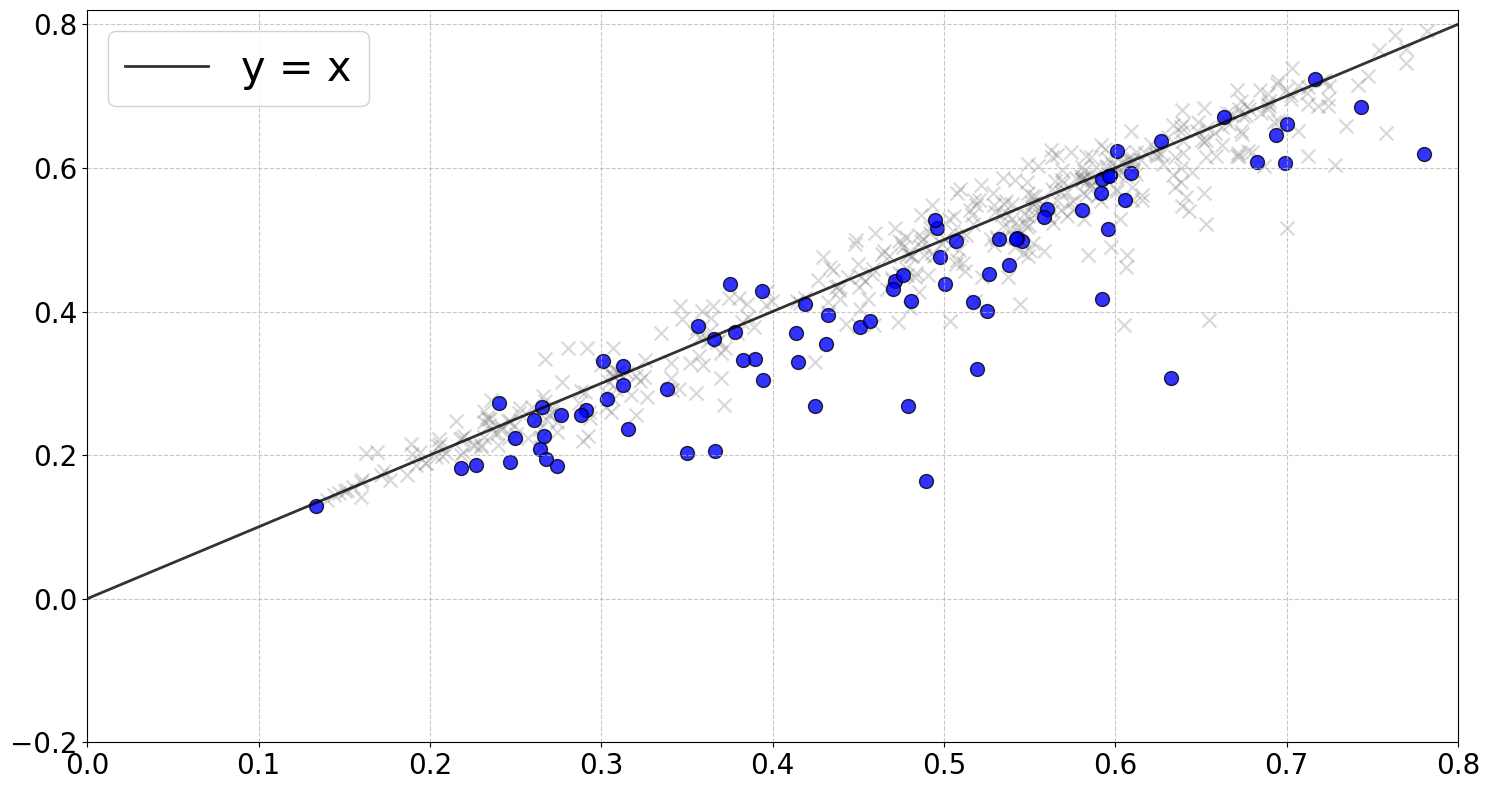

/tmp/ipykernel_1297349/748457844.py:79: UserWarning:

You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.



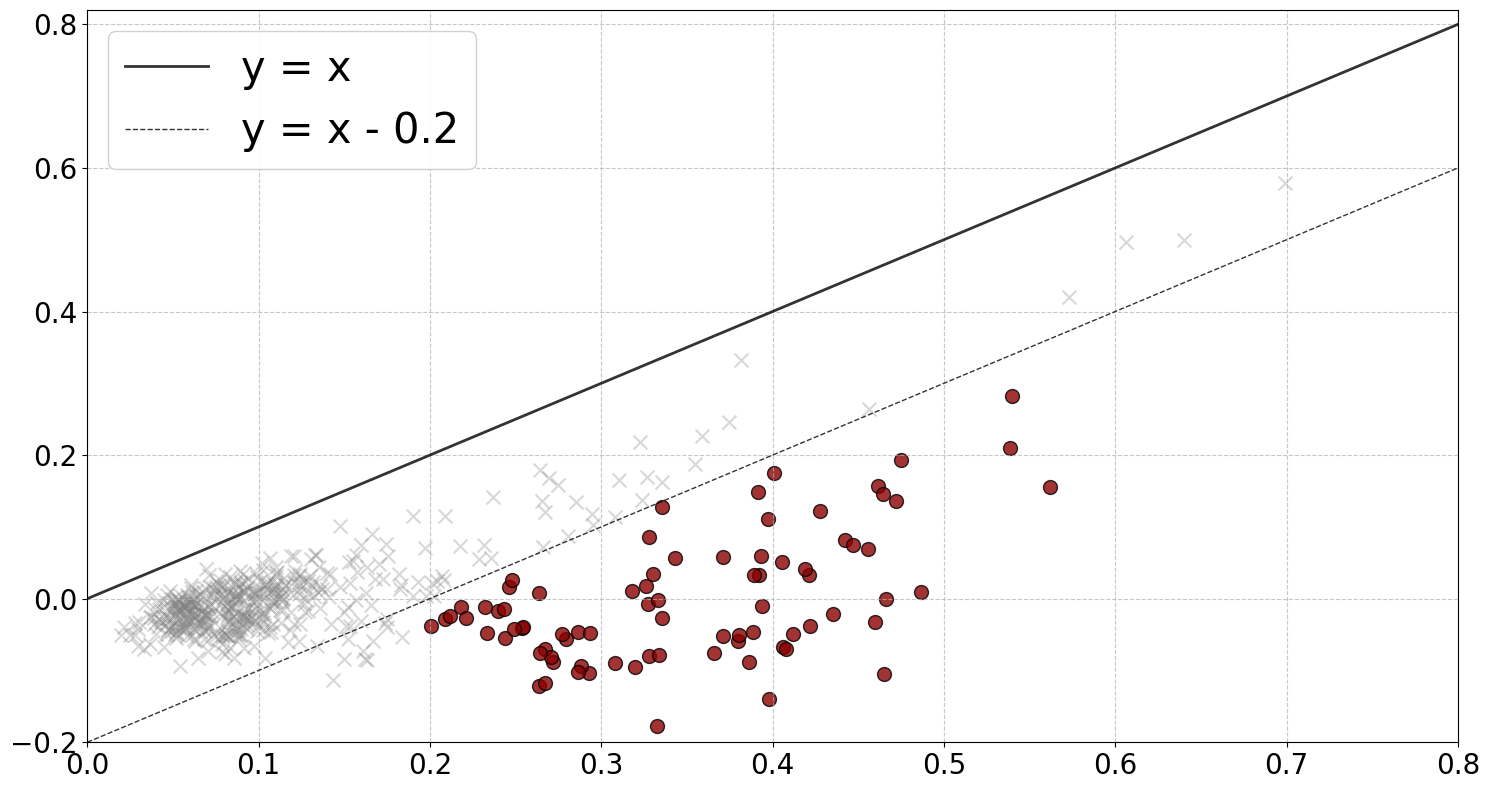

In [32]:
plot_analysis(results_df)

In [34]:
results_df.to_csv("../data/fig_4_data.csv", index=False)